In [91]:
#Importamos las librerias necesarias para el analisis de nuestra data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 


In [92]:
#Creamos la variable donde registramos la ruta donde se encuentra la data
path = r'datos/Ventas_CavaDorada_Final_V4.xlsx'

In [93]:
#Leemos nuestra data, en este caso es un archivo excel, y lo registramos en la varible df_ventas, una variable que usaremos muchas veces
df_ventas=pd.read_excel(path)

In [94]:
#Visualizamos aleatoramiente las filas de nuestra data
df_ventas.sample(5)

,id_venta,fecha,id_producto,producto,categoria,precio_uni,cantidad,venta_total,dia,mes
9639,VENTA-049,19/12/2025,PROD-061,Six Pack Mike Maracuyá 355 ml,Preparado,25.0,8,200.0,viernes,Diciembre
11346,VENTA-049,1/1/2026,PROD-046,Four Loko Green 473 ml,Preparado,11.0,6,66.0,jueves,Enero
11419,VENTA-183,1/1/2026,PROD-014,Golden 473 ml,Cerveza,4.5,8,36.0,jueves,Enero
14894,VENTA-075,20/2/2026,PROD-052,Maniak Mango Rush 500 ml,Preparado,6.5,1,6.5,viernes,Febrero
5285,VENTA-1780,26/10/2025,PROD-067,Inka Cola 600 ml,Gaseosa,3.5,3,10.5,domingo,Octubre


In [95]:
#Visulizamos el tipo de dato de cata columna de nuestra data para verificar si esta todo correcto
df_ventas.dtypes

id_venta           str
fecha              str
id_producto        str
producto           str
categoria          str
precio_uni     float64
cantidad         int64
venta_total    float64
dia                str
mes                str
dtype: object

In [96]:
#Visualizamos el total de filas y columnas de nuestra data , siendo el primer parametro las filas y el segundo las columnas
df_ventas.shape

(18023, 10)

In [97]:
#Visualizamos un resumen completo de nuestra data
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 18023 entries, 0 to 18022
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     18023 non-null  str    
 1   fecha        18023 non-null  str    
 2   id_producto  18023 non-null  str    
 3   producto     18023 non-null  str    
 4   categoria    18023 non-null  str    
 5   precio_uni   18023 non-null  float64
 6   cantidad     18023 non-null  int64  
 7   venta_total  18023 non-null  float64
 8   dia          18023 non-null  str    
 9   mes          18023 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 1.4 MB


In [98]:
#Visualizamos la información basica estadistica de todas las columnas de nuestra data
df_ventas.describe(include="all")

,id_venta,fecha,id_producto,producto,categoria,precio_uni,cantidad,venta_total,dia,mes
count,18023,18023,18023,18023,18023,18023.000000,18023.000000,18023.000000,18023,18023
unique,2553,302,290,290,24,NaN,NaN,NaN,7,11
top,VENTA-073,31/12/2025,PROD-277,"Combo After Office 2 (Ron Flor de Caña 750 ml,...",Combos,NaN,NaN,NaN,sábado,Diciembre
freq,131,299,404,404,4286,NaN,NaN,NaN,3653,2797
mean,NaN,NaN,NaN,NaN,NaN,24.019447,2.186928,48.844920,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22.234970,1.472027,52.571004,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,5.500000,1.000000,10.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,23.000000,2.000000,32.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,36.000000,3.000000,75.000000,NaN,NaN


In [99]:
#Visualizamos los valores nulos que existan en cada columna, en este obervamos que ninguno
df_ventas.isnull().sum()

id_venta       0
fecha          0
id_producto    0
producto       0
categoria      0
precio_uni     0
cantidad       0
venta_total    0
dia            0
mes            0
dtype: int64

In [100]:
#Top 5 transacciones por venta total
df_ventas.sort_values("venta_total", ascending=False).head(5)

,id_venta,fecha,id_producto,producto,categoria,precio_uni,cantidad,venta_total,dia,mes
14282,VENTA-165,13/2/2026,PROD-009,Twelve Pack Pilsen Pequeño 355 ml,Cerveza,45.0,12,540.0,viernes,Febrero
15938,VENTA-078,8/3/2026,PROD-009,Twelve Pack Pilsen Pequeño 355 ml,Cerveza,45.0,12,540.0,domingo,Marzo
16780,VENTA-129,22/3/2026,PROD-009,Twelve Pack Pilsen Pequeño 355 ml,Cerveza,45.0,12,540.0,domingo,Marzo
12283,VENTA-010,11/1/2026,PROD-132,Whisky Johnnie Walker Double Black 750 ml,Whisky,150.0,3,450.0,domingo,Enero
17116,VENTA-143,27/3/2026,PROD-132,Whisky Johnnie Walker Double Black 750 ml,Whisky,150.0,3,450.0,viernes,Marzo


Observamos que las 5 transacciones individuales mas altas en venta total corresponde a dos productos, 
Twelve Pack Pilsen Pequeño 355 ml	y Whisky  Johnnie Walker Double Black 750 ml, productos que en un solo movimiento de venta generaron la venta total mas alta 
porque el primer producto destaca por la gran cantidad que se compro, y el segundo producto por su alto precio.

In [101]:
#Top 5 transacciones por cantidad
df_ventas.sort_values("cantidad", ascending=False).head(5)

,id_venta,fecha,id_producto,producto,categoria,precio_uni,cantidad,venta_total,dia,mes
10223,VENTA-003,24/12/2025,PROD-016,Flying Fish 355 ml,Cerveza,4.5,12,54.0,miércoles,Diciembre
11449,VENTA-249,1/1/2026,PROD-062,Six Pack Mike Limón 355 ml,Preparado,25.0,12,300.0,jueves,Enero
12103,VENTA-236,10/1/2026,PROD-010,Cusqueña Negra 473 ml,Cerveza,6.5,12,78.0,sábado,Enero
14602,VENTA-085,15/2/2026,PROD-004,Six Pack Corona Extra 330 ml,Cerveza,28.0,12,336.0,domingo,Febrero
11611,VENTA-235,2/1/2026,PROD-012,Six Pack Cusqueña Negra Grande 473 ml,Cerveza,35.0,12,420.0,viernes,Enero


Obervamos que las 5 transacciones individuales mas altas por cantidad es de 12,
siendo hasta la fecha el mayor numero de cantidad que se a comprado un producto

In [102]:
#Hacemos el uso del binning, para agrupar los valores de los precios en categorias
bins=np.linspace(min(df_ventas["precio_uni"]), max(df_ventas["precio_uni"]),4)
group_category=["Precio Barato","Precio Moderado","Precio Caro"]
df_ventas["categoria_precio"]=pd.cut(df_ventas["precio_uni"],bins, labels=group_category, include_lowest=True)


In [103]:
#Apreciación de nuestra tabla al usar binning
df_ventas.sample(5)

,id_venta,fecha,id_producto,producto,categoria,precio_uni,cantidad,venta_total,dia,mes,categoria_precio
4810,VENTA-1669,22/10/2025,PROD-272,Combo Universitario 1 (Ron Cartavio Black 750 ...,Combos,36.0,1,36.0,miércoles,Octubre,Precio Barato
191,VENTA-364,19/6/2025,PROD-084,Agua Cielo Maracuyá 600 ml,Agua Saborizada,2.0,3,6.0,jueves,Junio,Precio Barato
9416,VENTA-257,16/12/2025,PROD-020,360 Maracuyá-Camu Camu 300 ml,Energizante,2.5,2,5.0,martes,Diciembre,Precio Barato
8468,VENTA-2571,30/11/2025,PROD-082,Agua San mateo 600 ml,Agua,2.0,1,2.0,domingo,Noviembre,Precio Barato
5861,VENTA-1925,2/11/2025,PROD-273,Combo Universitario 2 (Ron Cartavio Black 1 lt...,Combos,40.0,1,40.0,domingo,Noviembre,Precio Barato


In [104]:
#Distribucion de los rangos en base los precios del min al max 
df_ventas.groupby("categoria_precio")["precio_uni"].agg(["min","max"]).reset_index()

,categoria_precio,min,max
0,Precio Barato,1.0,50.0
1,Precio Moderado,52.0,95.0
2,Precio Caro,105.0,150.0


In [105]:
#Numero de veces y porcentaje donde cada transacción fue por cierta categoria de precios
count_category_price = df_ventas.groupby("categoria_precio")["id_venta"].nunique().reset_index()
count_category_price.columns = ["categoria_precio", "Transacciones"]
count_category_price["Porcentaje"] = (
    count_category_price["Transacciones"] / 
    count_category_price["Transacciones"].sum() * 100
).round(2)
count_category_price

,categoria_precio,Transacciones,Porcentaje
0,Precio Barato,2525,72.56
1,Precio Moderado,850,24.43
2,Precio Caro,105,3.02


El 72.56% de las transacciones incluyó al menos un producto de precio barato. El 24.43% incluyó al menos un producto moderado y el 3.02% incluyó al menos un producto caro. Estos porcentajes no son excluyentes, porque una misma transacción puede contener productos de diferentes rangos de precio.

In [106]:
#Numero de veces donde cada transacción fue por cierta categoria
count_categoria=df_ventas.groupby("categoria")["id_venta"].nunique().to_frame().reset_index()
count_categoria.columns= ["categoria", "transacciones"]
count_categoria.sort_values("transacciones", ascending=False)

,categoria,transacciones
6,Combos,1736
10,Gaseosa,1196
16,Preparado,1045
7,Complementos/Bartender,797
3,Cerveza,694
0,Agua,407
4,Chicle/Caramelo,368
1,Agua Saborizada,294
17,Ron,292
23,Whisky,239


Observamos que la categoría Combos lidera ampliamente el número de transacciones, apareciendo en un total de 1736 ventas distintas. Esto sugiere que los clientes frecuentemente incluyen productos de esta categoría dentro de sus compras, convirtiéndola en una de las categorías con mayor presencia y demanda en el negocio.
Asimismo, categorías como Gaseosa y Preparado también muestran una alta participación en las transacciones, lo que indica que son productos recurrentes dentro del consumo de los clientes.
Por otro lado, categorías como Conservas, Aguardientes y Anisados y Gin presentan una baja presencia en las ventas, apareciendo en pocas transacciones. Esto podría indicar una menor demanda, menor rotación o un consumo más específico de estos productos dentro del negocio.

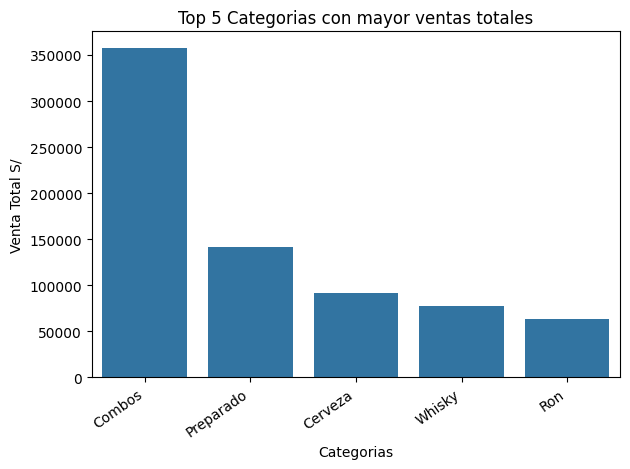

In [107]:
#Top 5 categorias que nos genera mas ventas
df_categoria_ventas_barras_grp=df_ventas.groupby("categoria")["venta_total"].sum().reset_index()
df_categoria_ventas_sort_desc=df_categoria_ventas_barras_grp.sort_values("venta_total", ascending=False).head(5)
sns.barplot(x="categoria", y="venta_total", data=df_categoria_ventas_sort_desc)
plt.title("Top 5 Categorias con mayor ventas totales")
plt.xlabel("Categorias")
plt.ylabel("Venta Total S/")
plt.xticks(rotation=35 , ha="right")
plt.tight_layout()
plt.savefig("imagenes/top_5_categorias_mayor_ventas.png", bbox_inches="tight")
plt.show()

La categoría Combos domina claramente las ventas totales, superando ampliamente al resto de categorías. Esta diferencia significativa sugiere que los clientes prefieren opciones agrupadas, probablemente por percepción de mayor valor o conveniencia.
La categoría Preparado ocupa el segundo lugar, aunque con una brecha considerable respecto a Combos, lo que indica que no existe una competencia directa fuerte en la categoría combos.
Este comportamiento sugiere una oportunidad estratégica para potenciar la venta de combos, así como analizar qué componentes los hacen más atractivos, con el fin de replicar ese éxito en otras categorías.

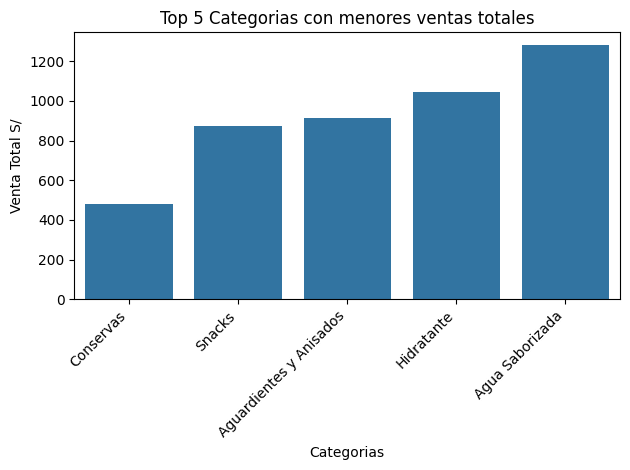

In [108]:
#Top 5 categorias que no genera muchos ingresos
df_categoria_ventas_sort_asc=df_categoria_ventas_barras_grp.sort_values("venta_total", ascending=True).head(5)
sns.barplot(x="categoria", y="venta_total", data=df_categoria_ventas_sort_asc)
plt.title("Top 5 Categorias con menores ventas totales")
plt.xlabel("Categorias")
plt.ylabel("Venta Total S/")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("imagenes/top_5_categorias_menor_ventas.png", bbox_inches="tight")
plt.show()

Observamos que la categoría Conservas presenta el menor nivel de ventas totales, seguida por Snacks y Aguardientes y Anisados, las cuales generaron ingresos inferiores a S/1000. Esto evidencia una baja participación de estas categorías dentro de las ventas generales del negocio.
Asimismo, aunque categorías como Hidratante y Agua Saborizada superan ligeramente los S/1000 en ventas, sus ingresos continúan siendo considerablemente menores en comparación con las categorías líderes del negocio.
Este comportamiento podría indicar una menor rotación o menor preferencia de los clientes hacia estos productos. Por ello, sería recomendable evaluar estrategias comerciales o promocionales que permitan incrementar su participación dentro de las ventas totales.

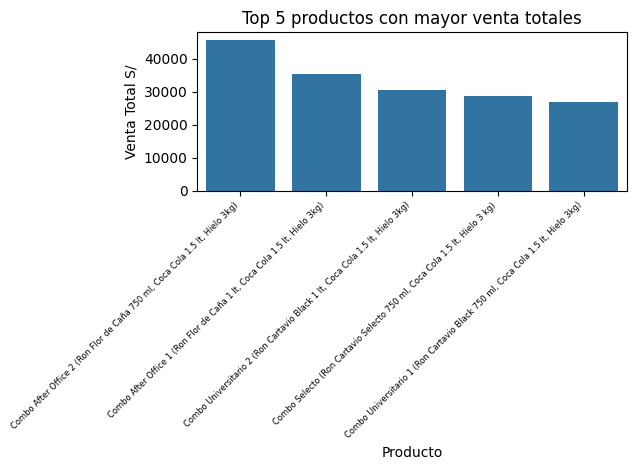

In [109]:
#Top 5 productos que genera mas ingresos 
df_producto_ventas_barras_grp=df_ventas.groupby("producto")["venta_total"].sum().reset_index()
df_producto_ventas_sort_desc= df_producto_ventas_barras_grp.sort_values("venta_total", ascending=False).head(5)
sns.barplot(x="producto", y="venta_total", data=df_producto_ventas_sort_desc)
plt.title("Top 5 productos con mayor venta totales")
plt.xlabel("Producto")
plt.ylabel("Venta Total S/")
plt.xticks(rotation=45, ha="right" , fontsize=6)
plt.tight_layout()
plt.savefig("imagenes/top_5_categorias_con_menores_ventas", bbox_inches="tight")
plt.show()

Observamos que los productos en Combo, especialmente el Combo After Office 2, lideran las ventas totales dentro del Top 5 de productos más vendidos. Asimismo, se aprecia que los demás productos con mayores ingresos también pertenecen a la categoría de combos, manteniendo niveles de ventas relativamente similares entre sí.
Este comportamiento sugiere una clara preferencia de los clientes por productos agrupados, posiblemente debido a la conveniencia, percepción de mayor valor o mejores beneficios frente a la compra individual de productos.
A partir de este análisis, se podría considerar como estrategia comercial continuar impulsando la venta de combos e incluso desarrollar nuevas combinaciones de productos con precios atractivos para los clientes, con el objetivo de mantener e incrementar los ingresos del negocio.

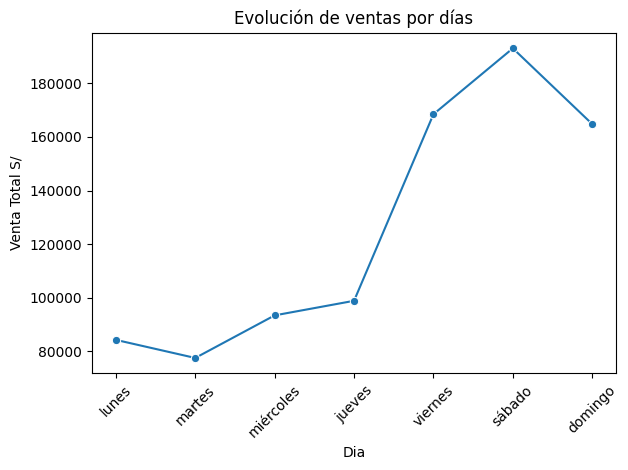

In [110]:
#Trayectoria de los dias con mas ingresos
df_dia_ventas_lineas_grp=df_ventas.groupby("dia")["venta_total"].sum().reset_index()
orden_dias = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
df_dia_ventas_lineas_grp["dia"] = pd.Categorical(df_dia_ventas_lineas_grp["dia"],categories=orden_dias, ordered=True)
sns.lineplot(x="dia", y="venta_total", data=df_dia_ventas_lineas_grp, marker="o")
plt.title("Evolución de ventas por días")
plt.xlabel("Dia")
plt.ylabel("Venta Total S/")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("imagenes/evolucion_ventas_por_dias" ,bbox_inches="tight")
plt.show()

Observamos que los días lunes, martes y miércoles presentan los niveles más bajos de ventas totales. Sin embargo, a partir del jueves las ventas comienzan a incrementarse progresivamente, alcanzando sus valores más altos durante viernes y sábado.
Este comportamiento sugiere un patrón de consumo asociado al cierre de la semana laboral y al inicio del fin de semana, donde los clientes posiblemente incrementan la compra de bebidas alcohólicas y productos relacionados para actividades sociales o de entretenimiento.
Asimismo, aunque el domingo mantiene un nivel de ventas elevado, se aprecia una ligera disminución respecto al sábado, lo que podría estar relacionado con el cierre de actividades del fin de semana y la preparación para el inicio de una nueva semana laboral.

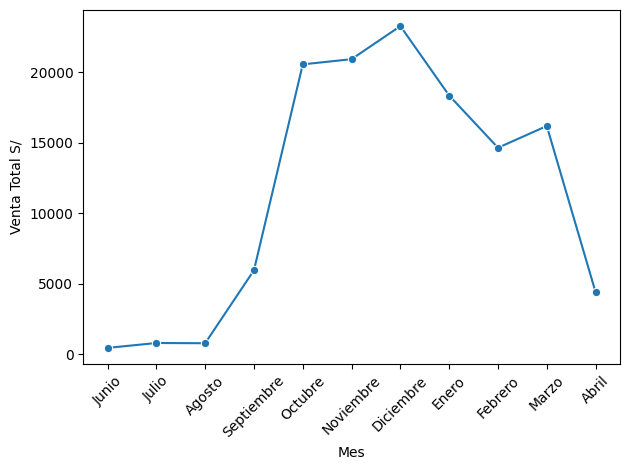

In [111]:
#Trayectoria de los meses en venta totales.
df_mes_venta_grp=df_ventas[["dia", "mes", "venta_total"]].groupby(["dia", "mes"], as_index=False).sum()
orden_mes=["Junio","Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre", "Enero", "Febrero", "Marzo","Abril"]
df_mes_venta_grp["mes"]=pd.Categorical(df_mes_venta_grp["mes"],categories=orden_mes, ordered=True)
df_mes_venta_grp=df_mes_venta_grp.sort_values("mes")
sns.lineplot(x="mes",y="venta_total",data=df_mes_venta_grp, marker="o",errorbar=None)
plt.xlabel("Mes")
plt.ylabel("Venta Total S/")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("imagenes/evolucion_meses_venta_total.png", bbox_inches="tight")
plt.show()

Observamos que durante junio, julio y agosto las ventas se mantuvieron en niveles relativamente bajos, lo cual podría estar relacionado con la etapa inicial de operación del negocio y un menor posicionamiento frente a los clientes.
Sin embargo, a partir de septiembre se aprecia un crecimiento significativo en las ventas, manteniéndose una tendencia positiva hasta alcanzar su punto más alto en diciembre. Este comportamiento podría estar asociado al incremento del consumo durante las festividades de fin de año y a una mayor demanda de bebidas alcohólicas en temporadas festivas.
Posteriormente, desde enero se observa una disminución progresiva en las ventas, posiblemente relacionada con la reducción de actividades festivas y un menor nivel de consumo al inicio del año.

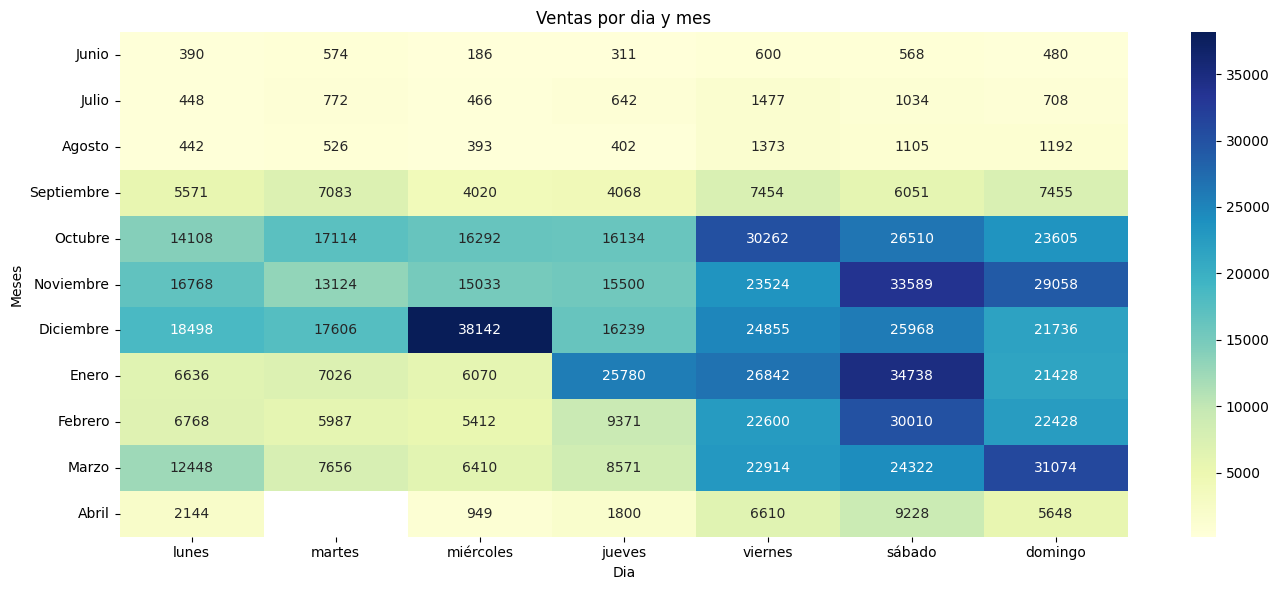

In [112]:
#Mapa de calor de ventas por dia y mes
df_mes_venta_grp["dia"]=pd.Categorical(df_mes_venta_grp["dia"], categories= orden_dias, ordered=True)
df_mes_venta_pvt=df_mes_venta_grp.pivot ( index="mes", columns="dia", values="venta_total")
plt.figure(figsize=(14,6))
sns.heatmap(df_mes_venta_pvt, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Ventas por dia y mes")
plt.xlabel("Dia")
plt.ylabel("Meses")
plt.tight_layout()
plt.savefig("imagenes/ventas_dias_y_mes.png", bbox_inches="tight")
plt.show()

Observamos que el mayor nivel de ventas se registra durante el mes de diciembre, específicamente los miércoles, alcanzando un monto aproximado de S/38,142. Asimismo, se aprecia que los días viernes, sábado y domingo concentran altos niveles de ventas en varios meses del año, especialmente entre octubre y marzo.
Por otro lado, los meses comprendidos entre junio y agosto presentan niveles de ventas considerablemente menores en comparación con los meses posteriores, lo que podría estar relacionado con la etapa inicial del negocio y una menor demanda durante ese periodo como se menciono anteriormente en la grafica de de lineas.
En general, el heatmap permite identificar una clara concentración de ventas hacia los fines de semana y durante los últimos meses del año, evidenciando un comportamiento estacional y una mayor actividad comercial en fechas cercanas a celebraciones y temporadas festivas.

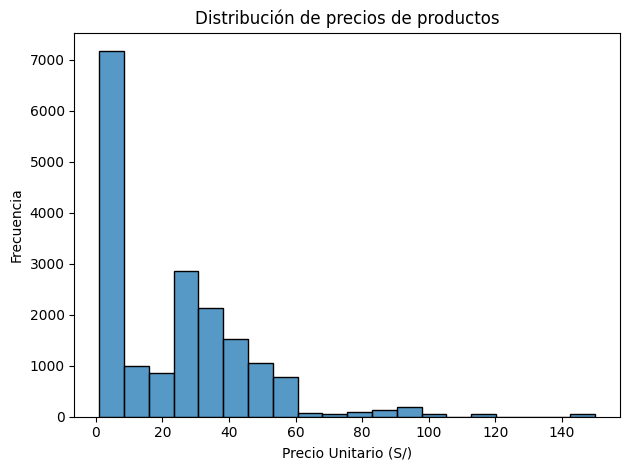

In [113]:
#Rango de precios que son mas frecuentes en ventas
sns.histplot(df_ventas["precio_uni"], bins=20)
plt.title("Distribución de precios de productos")
plt.xlabel("Precio Unitario (S/)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("imagenes/frecuencia_ventas_precio_productos", bbox_inches="tight")
plt.show()

Observamos que los precios unitarios bajos presentan la mayor frecuencia de aparición dentro de los registros de venta, especialmente en rangos entre S/1 y S/10. Esto indica que gran parte de las transacciones incluyen productos de bajo costo.
Asimismo, conforme el precio unitario aumenta, la frecuencia de aparición disminuye progresivamente, evidenciando una menor presencia de productos de precios elevados dentro de las ventas registradas.

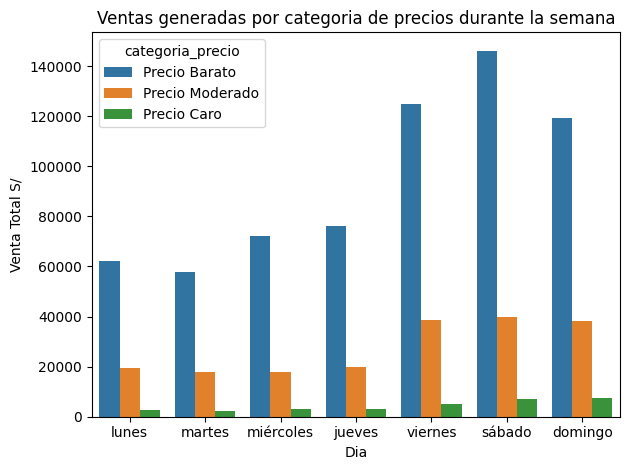

In [114]:
#Ventas totales generados por ciertas categorias de manera semanal
df_venta_categoria_precio = df_ventas[["categoria_precio", "dia", "venta_total"]].groupby(["categoria_precio","dia"]).sum().reset_index()
df_venta_categoria_precio["dia"]=pd.Categorical(df_venta_categoria_precio["dia"], categories=orden_dias, ordered=True)
sns.barplot(x="dia", y="venta_total", hue="categoria_precio", data=df_venta_categoria_precio)
plt.title("Ventas generadas por categoria de precios durante la semana")
plt.xlabel("Dia")
plt.ylabel("Venta Total S/")
plt.tight_layout()
plt.savefig("imagenes/venta_total_semanal_categoria_precio",bbox_inches="tight")
plt.show()

Observamos que la categoría de precios baratos genera los mayores niveles de ventas totales durante todos los días de la semana, especialmente entre viernes y domingo. Esto sugiere que los productos de menor precio presentan una mayor rotación y frecuencia de compra por parte de los clientes.
Por otro lado, las categorías de precios moderados y caros generan menores montos de ventas totales en comparación con los productos baratos, lo que indicaría que, aunque estos productos pueden tener precios más elevados, su volumen de venta es considerablemente menor.
Asimismo, se evidencia que los fines de semana concentran los mayores niveles de ventas para todas las categorías de precio, reflejando un incremento general del consumo durante dichos días.


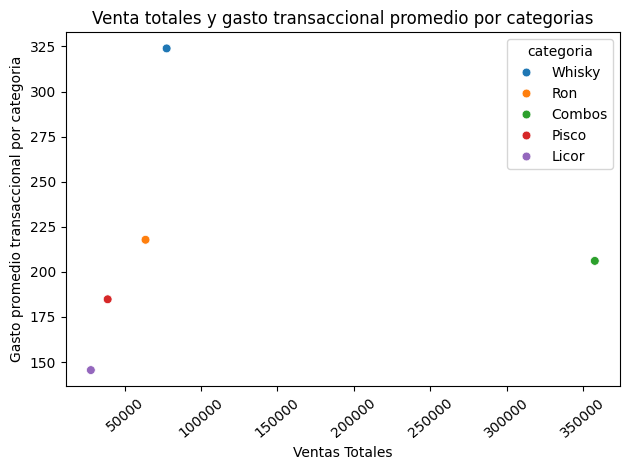

In [115]:
#Dispersion entre las ventas totales y gastos transaccional/venta transaccional promedio por categorias
df_comparacion_categoria=df_ventas.groupby("categoria").agg(
    transacciones=("id_venta","nunique"),
    venta_total=("venta_total","sum")
).reset_index()
df_comparacion_categoria["venta_promedio_transaccion"]=df_comparacion_categoria["venta_total"]/df_comparacion_categoria["transacciones"]
sns.scatterplot(data=df_comparacion_categoria.sort_values("venta_promedio_transaccion", ascending=False).head(5), x="venta_total", y="venta_promedio_transaccion", hue="categoria", s=40)
plt.title("Venta totales y gasto transaccional promedio por categorias")
plt.xlabel("Ventas Totales")
plt.ylabel("Gasto promedio transaccional por categoria")
plt.xticks(rotation=40)
plt.tight_layout()
plt.savefig("imagenes/venta_totales_transacciones_promedio_categoria",bbox_inches="tight")
plt.show()

Observamos que la categoría Whisky registra el ticket promedio más alto con aproximadamente S/323.92 por transacción, a pesar de no ser la categoría con mayor número de transacciones. Esto indica que las compras relacionadas con productos de whisky suelen generar montos elevados por cada venta realizada.
Por otro lado, la categoría Combos es la que concentra la mayor cantidad de transacciones con 1736 y además genera la mayor venta total acumulada con S/357775. Sin embargo, su ticket promedio (S/206.09) es menor al de Whisky y Ron, lo que sugiere que los combos destacan más por volumen de ventas y frecuencia de compra que por un gasto elevado en cada transacción.
Asimismo, categorías como Ron y Pisco también presentan tickets promedio altos, superiores a S/180 por transacción, lo cual evidencia que las bebidas alcohólicas premium o de mayor valor unitario tienden a generar compras con montos más elevados.
En general, los resultados sugieren que algunas categorías aportan ingresos mediante una alta frecuencia de compra (como Combos), mientras que otras generan valor a través de tickets promedio más altos por transacción (como Whisky y Ron).


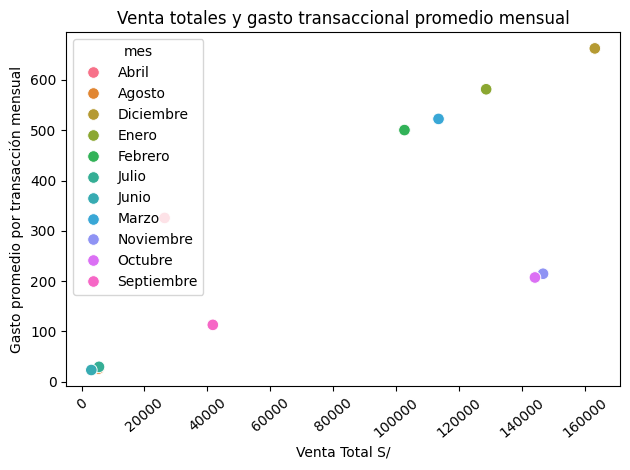

In [116]:
# Venta totales y gasto transaccional promedio mensual
df_comparacion_mes = df_ventas.groupby("mes").agg(
    transacciones=("id_venta", "nunique"),
    venta_total=("venta_total", "sum")
).reset_index()
df_comparacion_mes["venta_promedio_transaccion"] = df_comparacion_mes["venta_total"] / df_comparacion_mes["transacciones"]
sns.scatterplot(data=df_comparacion_mes, x="venta_total", y="venta_promedio_transaccion", hue="mes", s=70)
plt.title("Venta totales y gasto transaccional promedio mensual")
plt.xlabel("Venta Total S/")
plt.ylabel("Gasto promedio por transacción mensual")
plt.xticks(rotation=40)
plt.tight_layout()
plt.savefig("imagenes/venta_gasto_transaccional_promedio_mensual",bbox_inches="tight")
plt.show()

Observamos que diciembre registró tanto las mayores ventas totales como el ticket promedio más alto, alcanzando aproximadamente mas de S/600 por transacción. Esto sugiere que durante dicho mes no solo aumentó el volumen de ventas, sino también el valor promedio de compra por transacción.
Por otro lado, junio presentó el menor nivel de ventas y el ticket promedio más bajo con aproximadamente S/23.21 por transacción, evidenciando un comportamiento comercial considerablemente menor en comparación con los meses de cierre de año.
En general, el gráfico muestra una relación positiva entre las ventas totales y el gasto promedio por transacción, donde los meses con mayores ingresos tienden también a registrar tickets promedio más elevados.


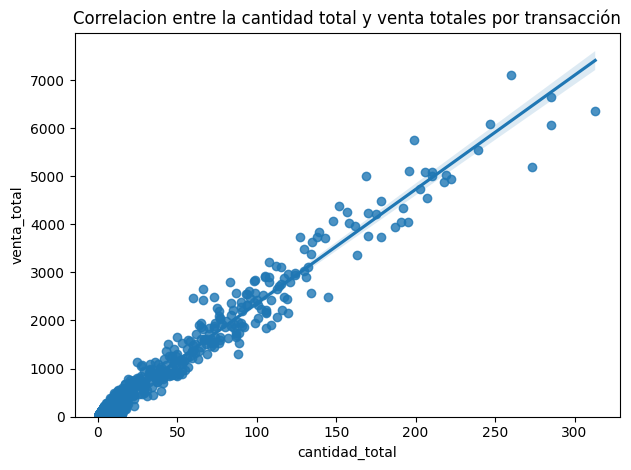

In [117]:
#correlacion entre la cantidad total y venta totales por cada transacción 
df_correlacion=df_ventas.groupby("id_venta").agg(
        cantidad_total=("cantidad","sum"),
        precio_promedio=("precio_uni","mean"),
        venta_total=("venta_total", "sum")
    )
sns.regplot(x="cantidad_total", y="venta_total", data=df_correlacion)
plt.ylim(0,)
plt.title("Correlacion entre la cantidad total y venta totales por transacción")
plt.tight_layout()
plt.savefig("imagenes/correlacion_cantidad_venta_total_transaccional",bbox_inches="tight")
plt.show()

Observamos una correlación positiva fuerte entre la cantidad total de productos comprados y la venta total generada por transacción. Esto indica que, en general, mientras mayor sea la cantidad de productos adquiridos en una compra, mayor será el monto total de la venta.
Asimismo, se aprecia que las transacciones con cantidades bajas suelen generar ventas menores, mientras que las compras con mayores cantidades alcanzan montos considerablemente más altos. Sin embargo, en los valores más elevados se observa una mayor dispersión de los puntos, lo que sugiere que la cantidad no es el único factor que influye en la venta total.
Este comportamiento podría estar relacionado con diferencias en los precios unitarios de los productos, donde algunas transacciones con cantidades similares generan montos distintos debido a la presencia de productos de precios más altos.


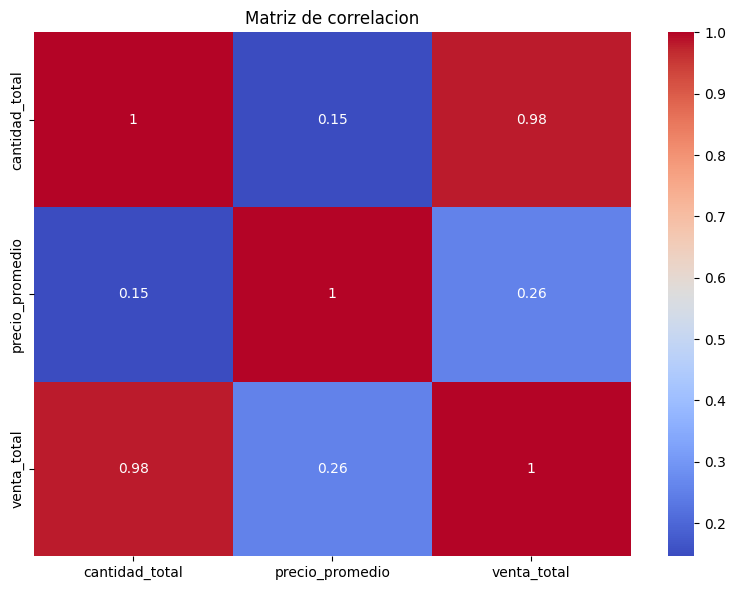

In [118]:
#Matriz de correalcion entre la cantidad tota, precio promedio de cada transacción y venta total , por transacciones
df_correlacion[["cantidad_total", "precio_promedio", "venta_total"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(df_correlacion[["cantidad_total", "precio_promedio", "venta_total"]].corr(),annot=True, cmap="coolwarm")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.savefig("imagenes/matrix_correlacion_cantidad_preciopromedio_venta_total",bbox_inches="tight")
plt.show()

La matriz de correlación evidencia que la variable con mayor relación respecto a la venta total es la cantidad total de productos adquiridos por transacción, con una correlación positiva extremadamente fuerte de 0.98. Esto indica que las ventas del negocio dependen principalmente del volumen de productos comprados en cada transacción.
Por otro lado, el precio promedio presenta una correlación positiva débil de 0.26 con la venta total, sugiriendo que el valor promedio de los productos influye en menor medida sobre el monto final de venta.
Asimismo, la correlación entre cantidad total y precio promedio es baja (0.15), indicando que las transacciones con mayores cantidades de productos no necesariamente incluyen productos más caros.
En conjunto, los resultados sugieren que el negocio genera mayores ingresos principalmente a través de compras de mayor volumen, más que por la venta de productos de precios elevados.


In [119]:
#Informacion de coeficiente de correlacion de Pearson entre la cantidat total y venta total , por transacciíon
pearson_coef, p_value = stats.pearsonr(df_correlacion["cantidad_total"],df_correlacion["venta_total"])
print("Coeficiente de Pearson : ", pearson_coef)
print("Valor P : ", p_value)


Coeficiente de Pearson :  0.980420970342541
Valor P :  0.0


El coeficiente de correlación de Pearson obtenido entre la cantidad total de productos por transacción y la venta total fue de 0.98, evidenciando una relación positiva extremadamente fuerte entre ambas variables. Esto indica que, a medida que aumenta la cantidad de productos adquiridos en una transacción, el monto total de venta también tiende a incrementarse significativamente.
Asimismo, el valor p obtenido fue cercano a 0, lo que demuestra que la relación encontrada es estadísticamente significativa y difícilmente atribuible al azar.
En conjunto, los resultados sugieren que el principal factor asociado al incremento de las ventas del negocio es el volumen de productos comprados por los clientes en cada transacción.


# Conclusiones generales

A partir del análisis exploratorio de datos realizado sobre las ventas de la licorería, se identificó que el negocio presenta un comportamiento fuertemente orientado al volumen de compra. La correlación de Pearson obtenida entre la cantidad total de productos por transacción y la venta total fue de 0.98, evidenciando una relación positiva extremadamente fuerte. Esto demuestra que el incremento de ingresos depende principalmente de la cantidad de productos adquiridos por los clientes en cada compra, más que del precio promedio de los productos.

Asimismo, la matriz de correlación mostró que el precio promedio de los productos mantiene una relación débil con la venta total (0.26), indicando que los productos más caros no necesariamente generan mayores ingresos globales, debido a que presentan una menor frecuencia de compra.

En cuanto al comportamiento temporal, se observó que los fines de semana, especialmente viernes, sábado y domingo, concentran los mayores niveles de ventas del negocio. El sábado registró el punto más alto de ingresos semanales, reflejando un mayor consumo durante dichos días.

A nivel mensual, diciembre presentó el mayor nivel de ventas y el ticket promedio más alto, lo que evidencia un incremento significativo del consumo en temporadas festivas. Por otro lado, junio, julio y agosto mostraron niveles considerablemente bajos de ventas, sugiriendo periodos de menor demanda comercial.

Respecto a las categorías de productos, “Combos” fue la categoría con mayores ingresos totales y mayor cantidad de transacciones, seguida de “Preparado”, “Cerveza”, “Whisky” y “Ron”. Esto sugiere que los clientes muestran una alta preferencia por productos agrupados o promociones combinadas.

Por el contrario, categorías como “Conservas”, “Snacks” y “Aguardientes y Anisados” registraron los menores niveles de ventas, evidenciando una baja rotación dentro del negocio.

Adicionalmente, el análisis por categorías de precio mostró que los productos clasificados como “Precio Barato” generan la mayor parte de las ventas totales durante toda la semana, especialmente los fines de semana. Esto confirma que el modelo comercial del negocio depende principalmente de productos económicos con alta frecuencia de compra.

# Recomendaciones

Se recomienda fortalecer las estrategias comerciales enfocadas en productos de alta rotación, especialmente en la categoría “Combos”, debido a su elevado impacto en las ventas totales. Asimismo, podrían implementarse nuevas promociones o paquetes similares para incrementar aún más el volumen de compra por transacción.

Dado que los fines de semana representan los días de mayor ingreso, se recomienda aumentar el abastecimiento de productos con mayor demanda durante viernes, sábado y domingo, evitando quiebres de stock en dichas fechas.

También se recomienda desarrollar estrategias específicas para las categorías con bajo desempeño comercial, como promociones, descuentos o campañas de visibilidad para productos de baja rotación, con el objetivo de incentivar su consumo y reducir posibles pérdidas por almacenamiento.

En relación con los meses de menor venta, sería conveniente implementar campañas promocionales o estrategias de fidelización durante junio, julio y agosto del presente año 2026, buscando mantener un flujo de ventas más estable a lo largo del año, sin embargo, recordemos que se registro menores ventas en esos meses del año 2025, donde el negocio recien aperturo y por tanto aun no tenia visibilidad y/o apego a los clientes, por lo que este año 2026, con el negocio ya con mas visibilidad, las ventas pueden ser muy buenas.

Finalmente, considerando que las ventas dependen principalmente del volumen de productos adquiridos, se recomienda priorizar estrategias orientadas al aumento de cantidad por compra, como promociones tipo “lleva más por menos”, descuentos por volumen o productos complementarios dentro de una misma transacción.
